# 4.2. Practica: Análisis, implementación y prueba de dos máquinas de aprendizaje no supervisado

## Introducción de la actividad

Las máquinas con aprendizaje no supervisado se utilizan cuando el sistema de aprendizaje necesita reconocer similitudes o características de los datos de entrada. El análisis, implementación y prueba de dos máquinas de aprendizaje no supervisado permitirá comprender el funcionamiento de forma clara y precisa.

## Propósito de la actividad

Comprender el funcionamiento de máquinas de aprendizaje no supervisado.

## Instrucciones

Analicé, implemente y pruebe al menos dos máquinas de aprendizaje no supervisado, la implementación de las máquinas será en el lenguaje de su preferencia. La práctica deberá contener:

Análisis de las máquinas de aprendizaje no supervisado (funcionamiento de las máquinas (algoritmos)).

Implementación de las máquinas de aprendizaje no supervisado (implementación de los algoritmos).

Prueba de las máquinas de aprendizaje no supervisado (prueba de los algoritmos).

Conclusiones.

Referencias en formato APA

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `numpy` | Operaciones vectoriales y construcción de arreglos para las métricas de evaluación |
| `pandas` | Inspección tabular del dataset y construcción de las tablas comparativas de métricas |
| `matplotlib` | Visualización de la distribución de los datos, el método del codo, el dendrograma y los clusters resultantes |
| `scikit-learn` | Preprocesamiento (`StandardScaler`), los dos algoritmos de clustering (`KMeans`, `AgglomerativeClustering`) y las métricas internas (`silhouette_score`, `davies_bouldin_score`, `calinski_harabasz_score`, `adjusted_rand_score`) |
| `scipy` | Cálculo de la matriz de enlace (`linkage`) y graficación del dendrograma (`dendrogram`) para el clustering jerárquico |

In [1]:
import sys
import subprocess
import importlib.util

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "scipy": "scipy",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import scipy

print(f"Python       {sys.version}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"scipy        {scipy.__version__}")

Python       3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy        2.3.3
pandas       2.3.3
matplotlib   3.10.7
scikit-learn 1.7.2
scipy        1.16.3


## Dataset: Mall Customer Segmentation Data

Se utiliza el dataset **Mall Customer Segmentation Data** (Vjchoudhary7, s.f.), publicado en Kaggle. Contiene el registro de 200 clientes de un centro comercial, obtenido a partir de sus tarjetas de membresía. A diferencia de los datasets usados en prácticas anteriores, **no trae una variable objetivo**: no hay una "clase correcta" de cliente contra la cual comparar — es precisamente el escenario que el aprendizaje no supervisado busca resolver: descubrir estructura (grupos de clientes) sin que nadie la haya etiquetado de antemano.

**Columnas:**
- `CustomerID`: identificador único (se descarta, no aporta información para el clustering).
- `Genre`: género del cliente (`Male`/`Female`) — se usa solo de forma descriptiva en el análisis exploratorio.
- `Age`: edad del cliente, en años.
- `Annual Income (k$)`: ingreso anual estimado, en miles de dólares.
- `Spending Score (1-100)`: puntaje asignado por el centro comercial según el comportamiento e historial de compra del cliente (100 = gasta mucho, 1 = gasta poco).

**Variables para el clustering:** `Annual Income (k$)` y `Spending Score (1-100)`. Es el par de variables con el que este dataset se usa clásicamente para segmentación: ambas son continuas, están en una escala numérica comparable y permiten graficar los clusters directamente en 2D, sin recurrir a una proyección como PCA.

**Tamaño:** 200 clientes.

El archivo (`Mall_Customers.csv`) se descargó una sola vez y se guardó junto a este notebook, para que la práctica sea reproducible sin depender de una conexión a internet en cada ejecución.

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print(f"Clientes: {df.shape[0]}, columnas: {df.shape[1]}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
df.head()

Clientes: 200, columnas: 5
Valores nulos: 0


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Análisis exploratorio

Antes de aplicar cualquier algoritmo de clustering conviene revisar cómo se distribuyen las variables y si, a simple vista, el par `Annual Income (k$)` / `Spending Score (1-100)` muestra alguna estructura de grupos.

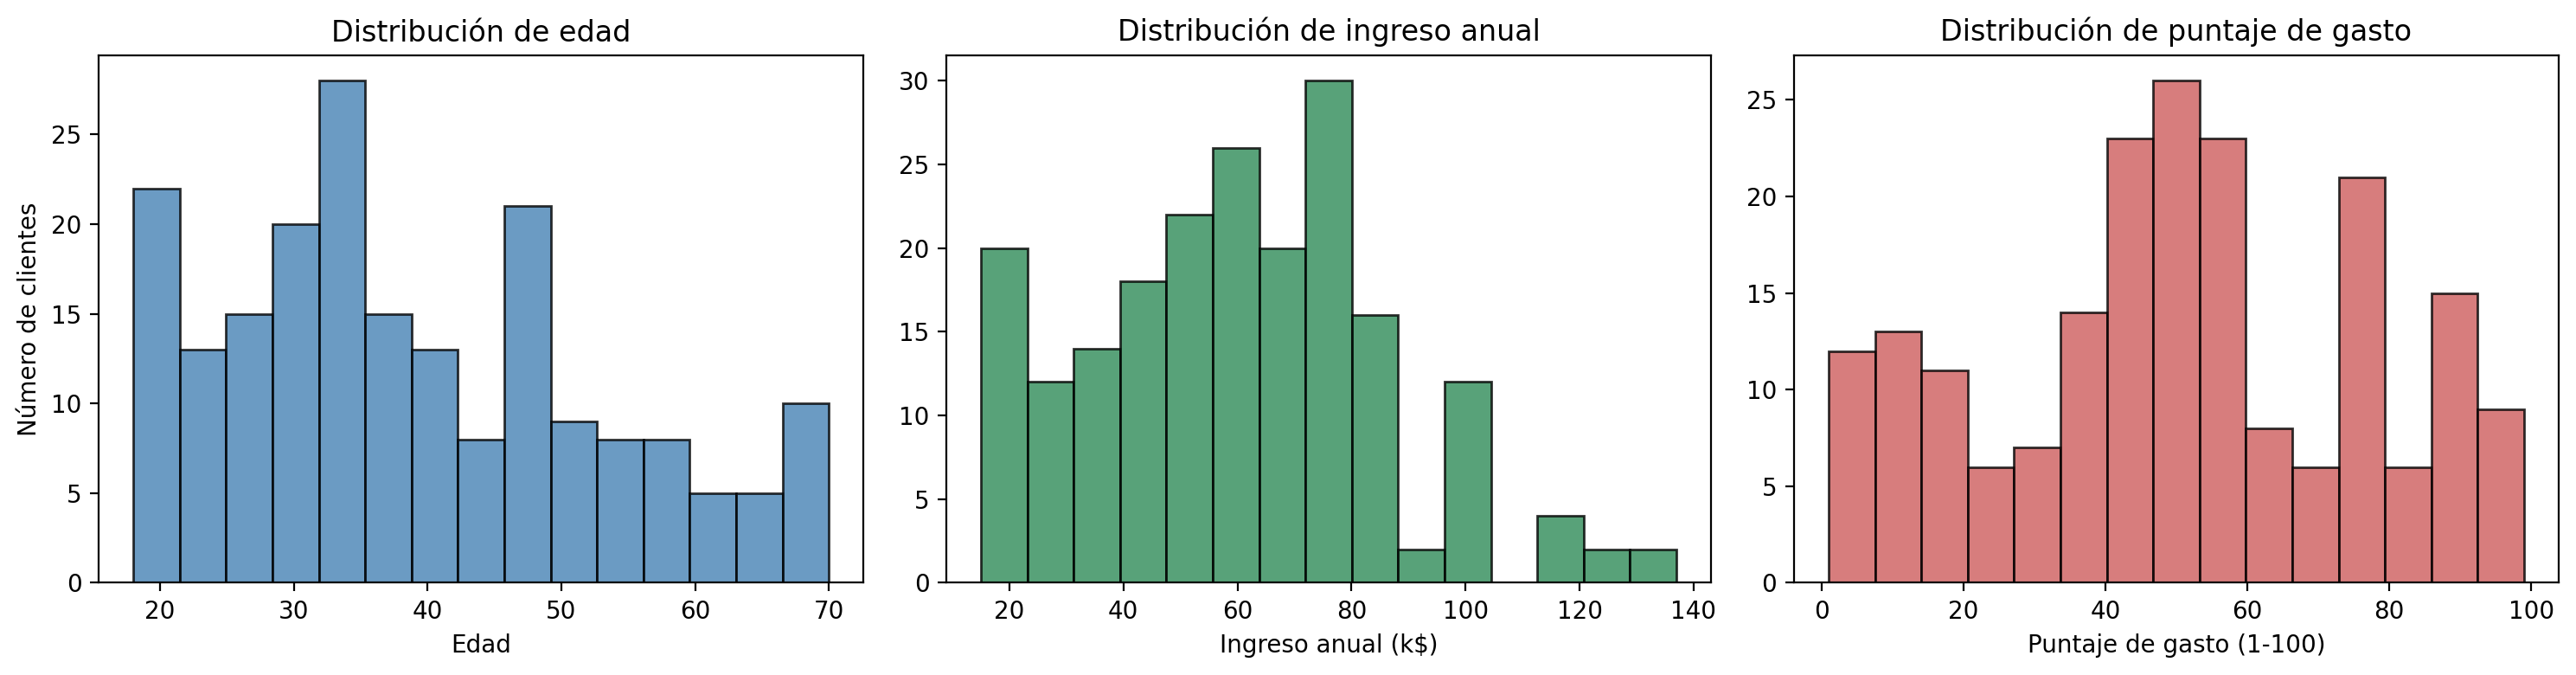

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=200)

axes[0].hist(df["Age"], bins=15, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Distribución de edad")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de clientes")

axes[1].hist(df["Annual Income (k$)"], bins=15, color="seagreen", edgecolor="black", alpha=0.8)
axes[1].set_title("Distribución de ingreso anual")
axes[1].set_xlabel("Ingreso anual (k$)")

axes[2].hist(df["Spending Score (1-100)"], bins=15, color="indianred", edgecolor="black", alpha=0.8)
axes[2].set_title("Distribución de puntaje de gasto")
axes[2].set_xlabel("Puntaje de gasto (1-100)")

plt.tight_layout()
plt.show()

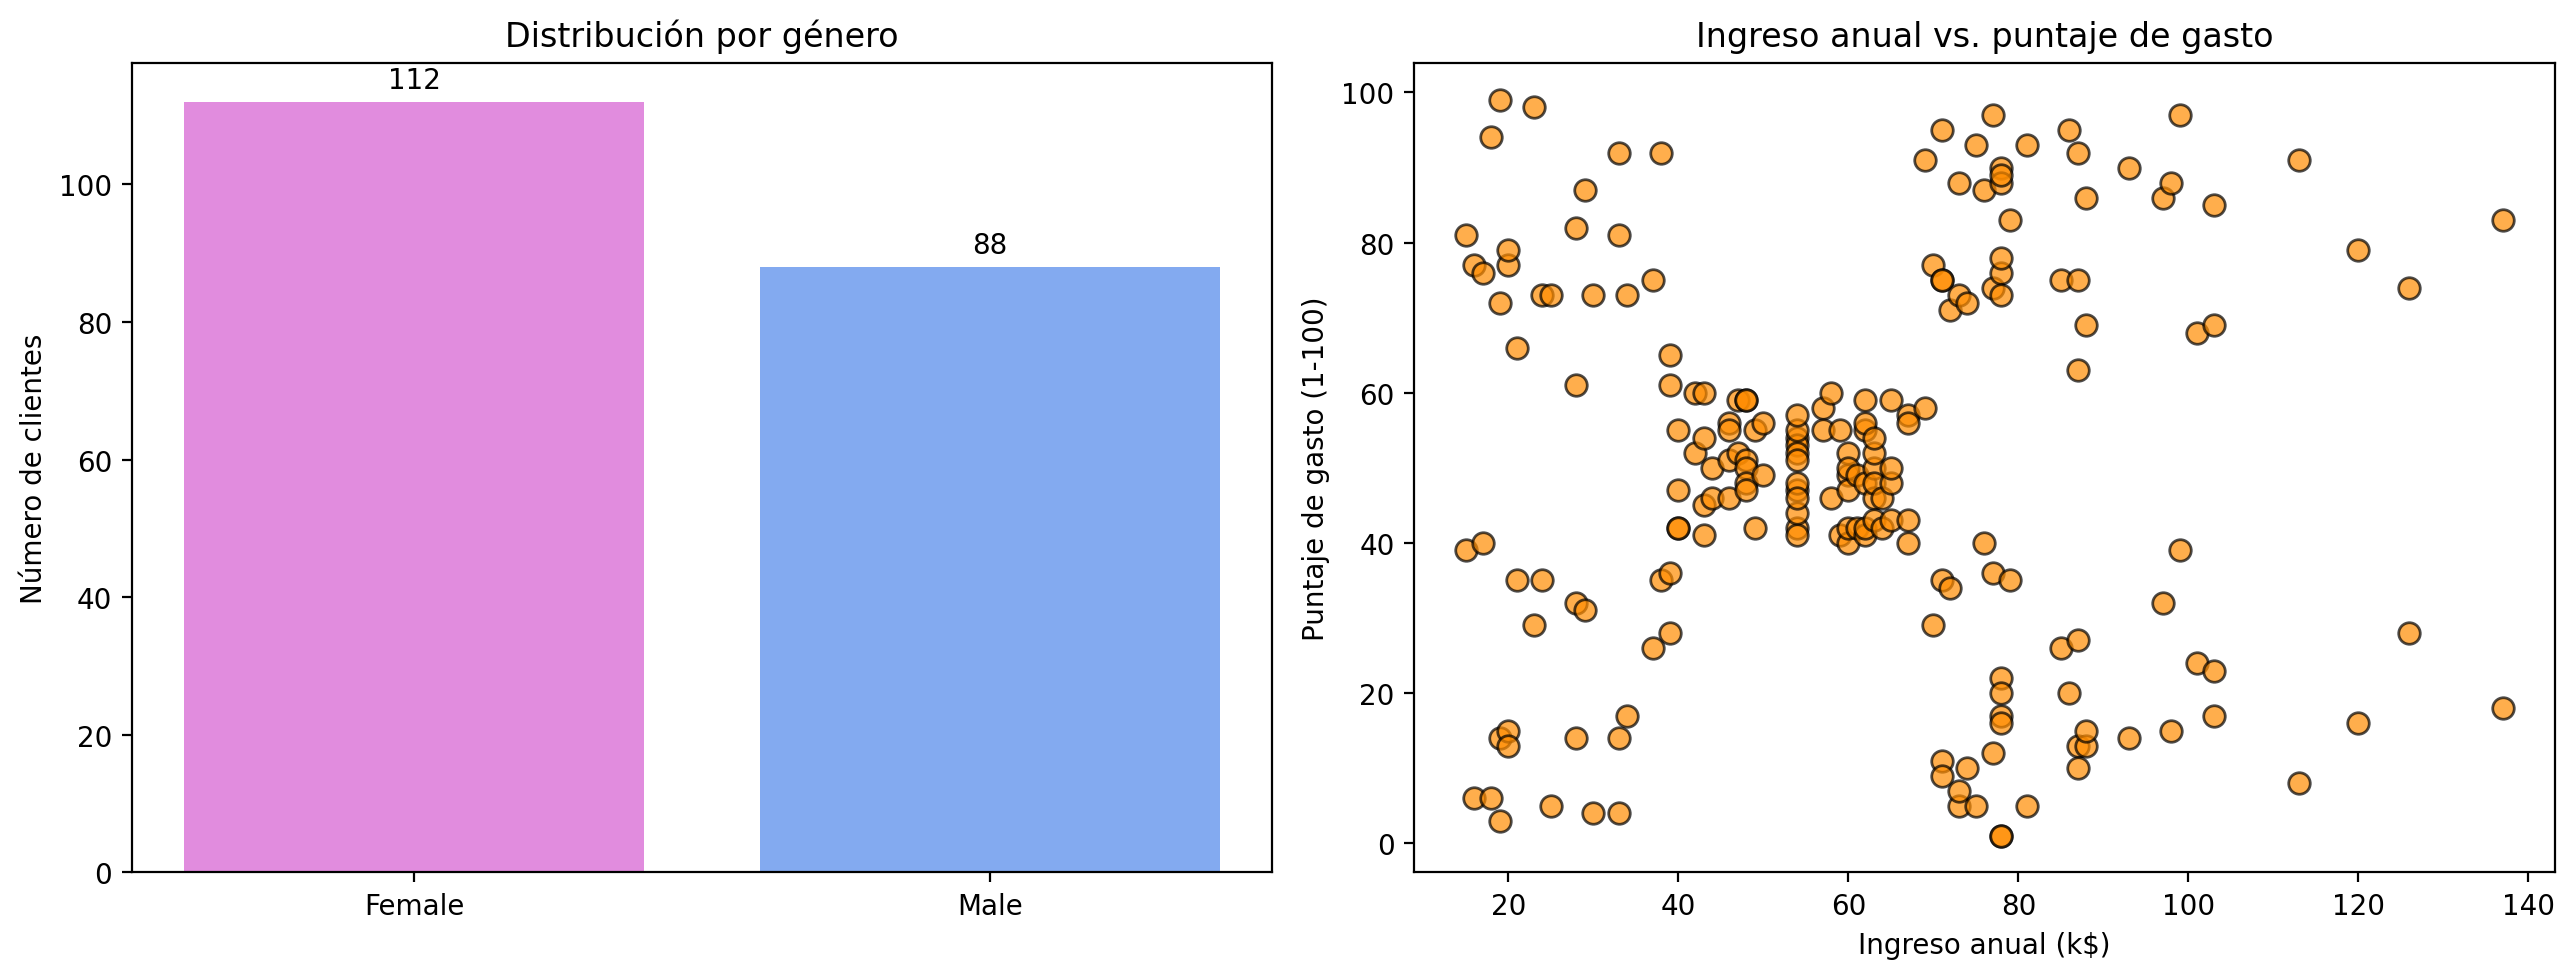

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

conteos_genero = df["Genre"].value_counts()
axes[0].bar(conteos_genero.index, conteos_genero.values, color=["orchid", "cornflowerblue"], alpha=0.8)
axes[0].set_title("Distribución por género")
axes[0].set_ylabel("Número de clientes")
for i, v in enumerate(conteos_genero.values):
    axes[0].text(i, v + 2, str(v), ha="center")

axes[1].scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
                s=60, color="darkorange", edgecolors="black", alpha=0.7)
axes[1].set_title("Ingreso anual vs. puntaje de gasto")
axes[1].set_xlabel("Ingreso anual (k$)")
axes[1].set_ylabel("Puntaje de gasto (1-100)")

plt.tight_layout()
plt.show()

# Análisis de las máquinas de aprendizaje no supervisado

## ¿Qué es el aprendizaje no supervisado y el clustering?

En el aprendizaje **supervisado** (Prácticas 1 a 3) cada muestra viene acompañada de una etiqueta correcta ($y$), y el objetivo del modelo es aprender la función que relaciona las características ($X$) con esa etiqueta. En el aprendizaje **no supervisado** no existe tal etiqueta: solo se dispone de $X$, y el objetivo es **descubrir estructura** en los datos por cuenta propia — qué muestras se parecen entre sí, qué grupos naturales emergen, sin que nadie los haya definido de antemano.

El **clustering** (agrupamiento) es la tarea no supervisada más común: dado un conjunto de $n$ muestras, se busca una partición en $k$ grupos (clusters) tal que las muestras dentro de un mismo grupo sean lo más parecidas posible entre sí, y lo más distintas posible de las muestras de otros grupos. En esta práctica se comparan dos algoritmos con filosofías muy distintas para lograrlo: **K-Means** (basado en centroides, particional) y **clustering jerárquico aglomerativo** (basado en fusiones sucesivas, jerárquico).

## K-Means

K-Means busca la partición en $k$ clusters que **minimiza la suma de las distancias al cuadrado entre cada punto y el centroide de su cluster** (la inercia o *within-cluster sum of squares*, WCSS):

$$J = \sum_{c=1}^{k} \sum_{x_i \in C_c} \|x_i - \mu_c\|^2$$

donde $\mu_c$ es el centroide (media) del cluster $C_c$. Encontrar la partición óptima exacta es computacionalmente inviable para datasets grandes, así que K-Means la aproxima con el **algoritmo de Lloyd**, un proceso iterativo de dos pasos que se repite hasta la convergencia:

1. **Asignación:** cada punto $x_i$ se asigna al cluster cuyo centroide $\mu_c$ le queda más cerca (distancia euclidiana).
2. **Actualización:** cada centroide $\mu_c$ se recalcula como la media de todos los puntos asignados a su cluster.

El algoritmo converge cuando las asignaciones dejan de cambiar entre una iteración y la siguiente. Como el resultado depende de dónde se colocaron los centroides iniciales, scikit-learn usa por defecto la inicialización **k-means++**, que escoge los centroides iniciales de forma que queden alejados entre sí (en lugar de puramente al azar), reduciendo el riesgo de converger a un mínimo local pobre; además, `n_init` controla cuántas veces se repite todo el proceso con distintas inicializaciones, quedándose con la de menor inercia.

**¿Cómo elegir $k$?** A diferencia del aprendizaje supervisado, aquí no hay una etiqueta contra la cual validar, así que $k$ se elige con métricas internas:

- **Método del codo:** se grafica la inercia final para distintos valores de $k$. La inercia siempre decrece al aumentar $k$ (con $k=n$ sería cero), pero típicamente decrece rápido al principio y luego se aplana — el "codo" de esa curva es un candidato razonable para $k$.
- **Coeficiente de silueta:** para cada punto $i$, compara qué tan bien encaja en su propio cluster frente a qué tan bien encajaría en el cluster vecino más cercano:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

donde $a(i)$ es la distancia media de $i$ a los demás puntos de su propio cluster, y $b(i)$ es la distancia media de $i$ a los puntos del cluster vecino más cercano. $s(i)$ va de $-1$ (mal asignado) a $1$ (perfectamente asignado); se promedia sobre todos los puntos para obtener una silueta global por cada $k$, y se elige el $k$ que la maximiza.

**Limitaciones:** K-Means asume implícitamente clusters de forma aproximadamente esférica y tamaño similar (por cómo se define la distancia al centroide), requiere fijar $k$ de antemano, es sensible a la escala de las variables (de ahí la necesidad de estandarizar con `StandardScaler` antes de aplicarlo) y sensible a outliers (que pueden desplazar la media de un cluster).

## Clustering Jerárquico (Aglomerativo)

El clustering jerárquico aglomerativo construye la partición de abajo hacia arriba (*bottom-up*):

1. Se parte de $n$ clusters, uno por cada muestra.
2. En cada paso se **fusionan los dos clusters más cercanos** entre sí, quedando con un cluster menos.
3. Se repite el paso 2 hasta que todas las muestras quedan en un único cluster.

Este proceso no requiere fijar $k$ de antemano: registra el historial completo de fusiones en un **dendrograma**, un árbol donde la altura de cada fusión representa la distancia entre los clusters fusionados. Una vez construido el dendrograma, se puede obtener una partición en cualquier número de clusters **cortándolo horizontalmente** a una altura determinada: cada rama que la línea de corte atraviesa define un cluster.

**¿Qué significa "los dos clusters más cercanos"?** Entre puntos individuales la distancia es directa (euclidiana), pero entre *clusters* (conjuntos de puntos) hace falta un criterio de enlace (*linkage*):

- **Enlace simple (*single*):** distancia entre los dos puntos más cercanos de cada cluster (tiende a producir clusters alargados, encadenados).
- **Enlace completo (*complete*):** distancia entre los dos puntos más lejanos de cada cluster (favorece clusters compactos).
- **Enlace promedio (*average*):** promedio de las distancias entre todos los pares de puntos de ambos clusters.
- **Enlace de Ward (*ward*):** en cada paso fusiona el par de clusters cuya unión produce el **menor incremento posible en la varianza intra-cluster total**. Es el criterio usado en esta práctica por ser el que, en la práctica, suele producir clusters más compactos y de tamaño más equilibrado — un objetivo similar en espíritu al de K-Means (minimizar varianza intra-cluster), lo que lo hace especialmente comparable con él.

**Diferencias frente a K-Means:**

- No requiere decidir $k$ antes de ejecutar el algoritmo: se puede inspeccionar el dendrograma completo y decidir dónde cortarlo después.
- Es **determinista**: no depende de una inicialización aleatoria de centroides: dos ejecuciones sobre los mismos datos con el mismo *linkage* siempre producen el mismo dendrograma.
- Es más costoso computacionalmente ($O(n^2 \log n)$ frente a $O(n \cdot k \cdot t)$ de K-Means, con $t$ iteraciones), lo que lo hace poco práctico para datasets muy grandes.
- No asume implícitamente que los clusters sean esféricos (dependiendo del *linkage* usado), aunque con enlace de Ward la tendencia hacia clusters compactos es similar a la de K-Means.

# Implementación

## Preprocesamiento

Tanto K-Means como el clustering jerárquico con enlace de Ward calculan distancias euclidianas entre puntos, por lo que son sensibles a la escala de las variables: sin estandarizar, `Annual Income (k$)` (que va de ~15 a ~140) dominaría por completo la distancia frente a `Spending Score (1-100)` simplemente por tener una magnitud numérica mayor, no porque sea más relevante. Se estandarizan ambas variables con `StandardScaler` (media 0, desviación estándar 1) antes de aplicar cualquiera de los dos algoritmos.

In [5]:
from sklearn.preprocessing import StandardScaler

variables = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[variables].values

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

print(f"Variables usadas: {variables}")
print(f"Media tras escalado:              {X_scaled.mean(axis=0)}")
print(f"Desviación estándar tras escalado: {X_scaled.std(axis=0)}")

Variables usadas: ['Annual Income (k$)', 'Spending Score (1-100)']
Media tras escalado:              [-2.13162821e-16 -1.46549439e-16]
Desviación estándar tras escalado: [1. 1.]


## K-Means

Se barre $k$ entre 2 y 10 para elegir el número de clusters con el método del codo y el coeficiente de silueta.

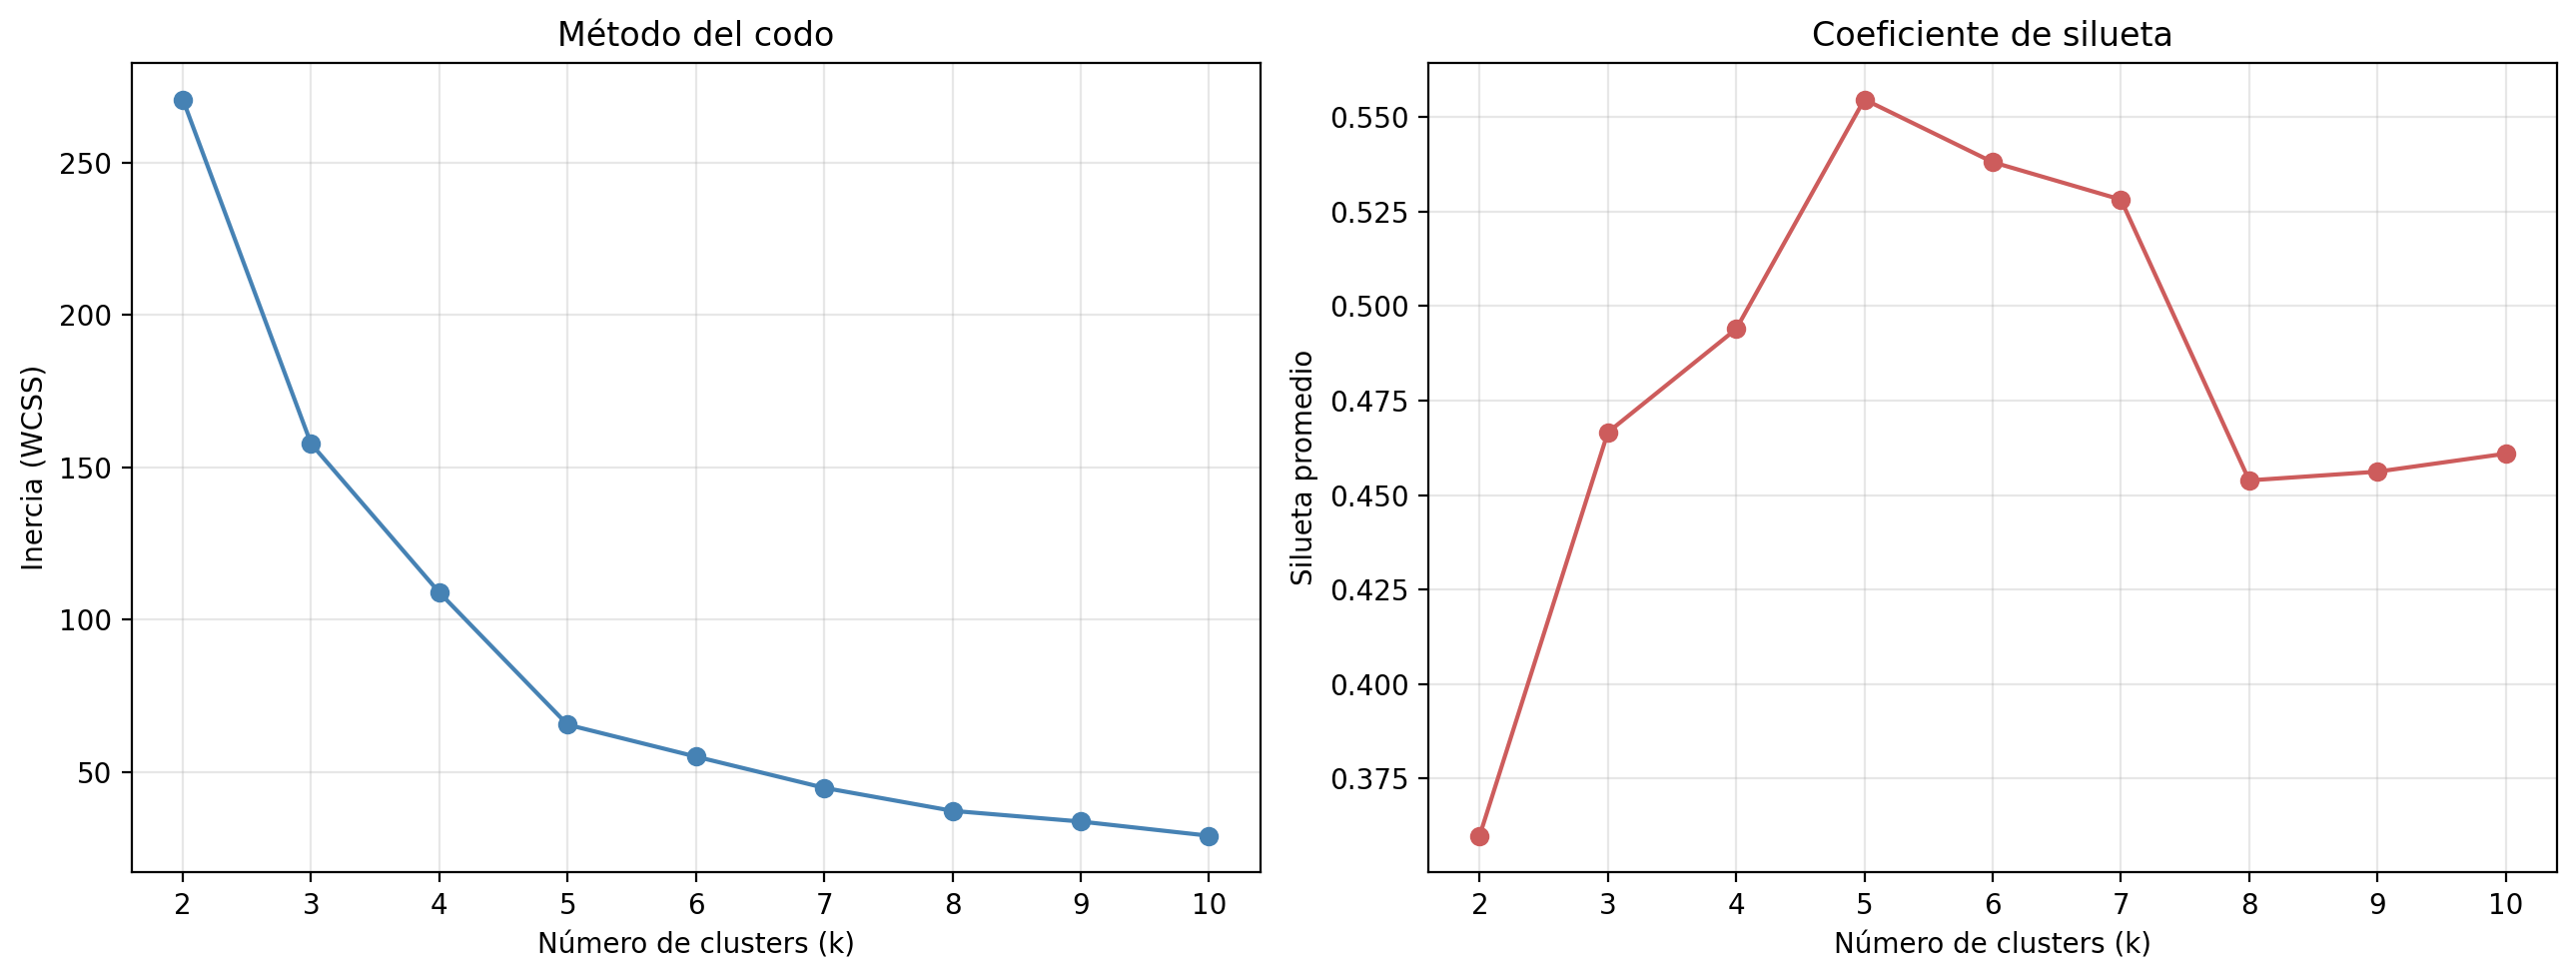

k con mayor silueta: 5 (silueta = 0.5547)


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rango_k = range(2, 11)
inercias = []
siluetas = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=26).fit(X_scaled)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_scaled, modelo.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

axes[0].plot(list(rango_k), inercias, marker="o", color="steelblue")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].grid(alpha=0.3)

axes[1].plot(list(rango_k), siluetas, marker="o", color="indianred")
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silueta promedio")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

k_optimo = list(rango_k)[int(np.argmax(siluetas))]
print(f"k con mayor silueta: {k_optimo} (silueta = {max(siluetas):.4f})")

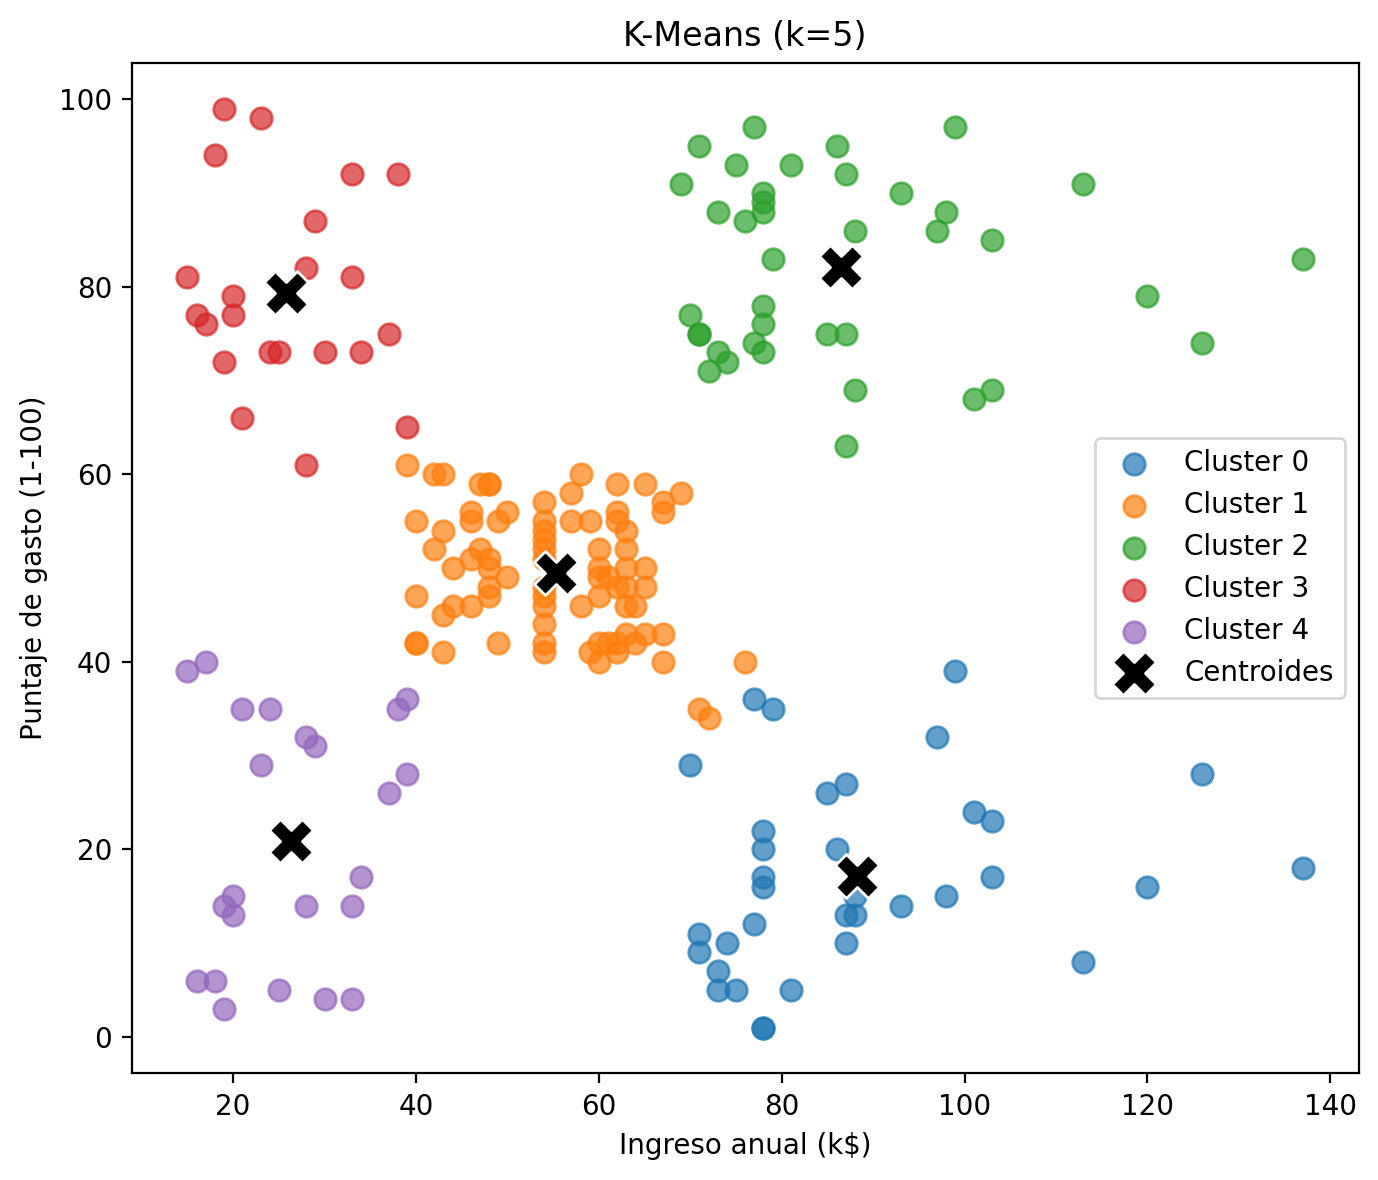

K-Means: mediana de tiempo de ajuste sobre 30 repeticiones = 0.0262 s


In [7]:
import time

kmeans = KMeans(n_clusters=k_optimo, init="k-means++", n_init=10, random_state=26)
labels_kmeans = kmeans.fit_predict(X_scaled)
centroides_kmeans = scaler.inverse_transform(kmeans.cluster_centers_)

# Se repite el ajuste varias veces y se toma la mediana: con un dataset tan pequeño (200 muestras)
# una sola medición es demasiado ruidosa (depende de la planificación del sistema operativo).
tiempos_kmeans = []
for _ in range(30):
    t0 = time.perf_counter()
    KMeans(n_clusters=k_optimo, init="k-means++", n_init=10, random_state=26).fit(X_scaled)
    tiempos_kmeans.append(time.perf_counter() - t0)
tiempo_kmeans = float(np.median(tiempos_kmeans))

plt.figure(figsize=(7, 6), dpi=200)
for c in range(k_optimo):
    plt.scatter(X[labels_kmeans == c, 0], X[labels_kmeans == c, 1], s=60, alpha=0.7, label=f"Cluster {c}")
plt.scatter(centroides_kmeans[:, 0], centroides_kmeans[:, 1], marker="X", s=250, color="black",
            linewidths=1, edgecolors="white", label="Centroides")
plt.title(f"K-Means (k={k_optimo})")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntaje de gasto (1-100)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"K-Means: mediana de tiempo de ajuste sobre 30 repeticiones = {tiempo_kmeans:.4f} s")

In [9]:
df_clusters = df.copy()
df_clusters["Cluster"] = labels_kmeans

resumen_clusters = df_clusters.groupby("Cluster")[variables].agg(["mean", "std"]).round(2)
resumen_clusters["Clientes"] = df_clusters["Cluster"].value_counts().sort_index()
resumen_clusters

Annual Income (k$)        Spending Score (1-100)        Clientes
                      mean    std                   mean    std         
Cluster                                                                 
0                    88.20  16.40                  17.11   9.95       35
1                    55.30   8.99                  49.52   6.53       81
2                    86.54  16.31                  82.13   9.36       39
3                    25.73   7.57                  79.36  10.50       22
4                    26.30   7.89                  20.91  13.02       23

### Perfil de negocio de los 5 segmentos

El **índice de cada cluster es arbitrario** (depende de la inicialización de k-means++, no tiene un orden intrínseco); lo que importa es el patrón que forma cada centroide en el plano ingreso-gasto. Con los centroides desescalados (`centroides_kmeans`) y la tabla de medias anterior, los 5 segmentos son:

| Cluster | Ingreso anual (k$) | Puntaje de gasto | Clientes | Perfil |
|---|---|---|---|---|
| 0 | ~88.2 | ~17.1 | 35 (17.5%) | Ingreso alto, gasto bajo — **ahorradores/cautelosos** |
| 1 | ~55.3 | ~49.5 | 81 (40.5%) | Ingreso medio, gasto medio — **clientes "estándar"** |
| 2 | ~86.5 | ~82.1 | 39 (19.5%) | Ingreso alto, gasto alto — **clientes objetivo / premium** |
| 3 | ~25.7 | ~79.4 | 22 (11.0%) | Ingreso bajo, gasto alto — **gastadores impulsivos con recursos limitados** |
| 4 | ~26.3 | ~20.9 | 23 (11.5%) | Ingreso bajo, gasto bajo — **bajo valor / cauteloso** |

**Lectura de resultados:**

- El segmento más grande, por mucho, es el **cluster 1** (81 clientes, 40.5% del total): ingreso y gasto medios, sin comportamiento extremo en ninguna dirección — es el "cliente típico" del centro comercial, y también el que ocupa la posición central del plano, lo que explica por qué en el silhouette plot es el vecino más cercano de casi todos los demás clusters.
- Los dos segmentos de mayor interés comercial son los "polos" de ingreso alto: el **cluster 2** (ingreso alto + gasto alto, 39 clientes) reúne a los clientes más valiosos — tienen tanto la capacidad económica como la disposición a gastar, y son candidatos naturales a programas de fidelización o marketing dirigido. El **cluster 0** (ingreso alto + gasto bajo, 35 clientes) tiene la misma capacidad económica pero no la está usando en el centro comercial — es el segmento con mayor potencial de crecimiento si se identifica por qué gastan poco (oferta poco relevante para su perfil, preferencia por otros canales, etc.).
- El **cluster 3** (ingreso bajo + gasto alto, 22 clientes, el más pequeño) es interesante por el motivo opuesto: gastan por encima de lo que su ingreso haría esperar, lo que sugiere mayor sensibilidad a promociones o compras impulsivas — un segmento pequeño pero de comportamiento distintivo.
- El **cluster 4** (ingreso bajo + gasto bajo, 23 clientes) es el de menor prioridad comercial inmediata: ni tienen alta capacidad de gasto ni la están ejerciendo.

Esta segmentación es consistente con la interpretación clásica que suele darse a este dataset (el patrón en forma de "X" o estrella visible en el scatter de la celda anterior): cuatro grupos en las esquinas del plano ingreso-gasto más un grupo central que concentra al cliente promedio.

## Clustering Jerárquico

Se calcula la matriz de enlace con `scipy.cluster.hierarchy.linkage` (enlace de Ward) y se grafica el dendrograma completo. La línea horizontal marca la altura de corte necesaria para obtener el mismo número de clusters ($k$ óptimo) que se usó en K-Means, para poder comparar ambos algoritmos en igualdad de condiciones.

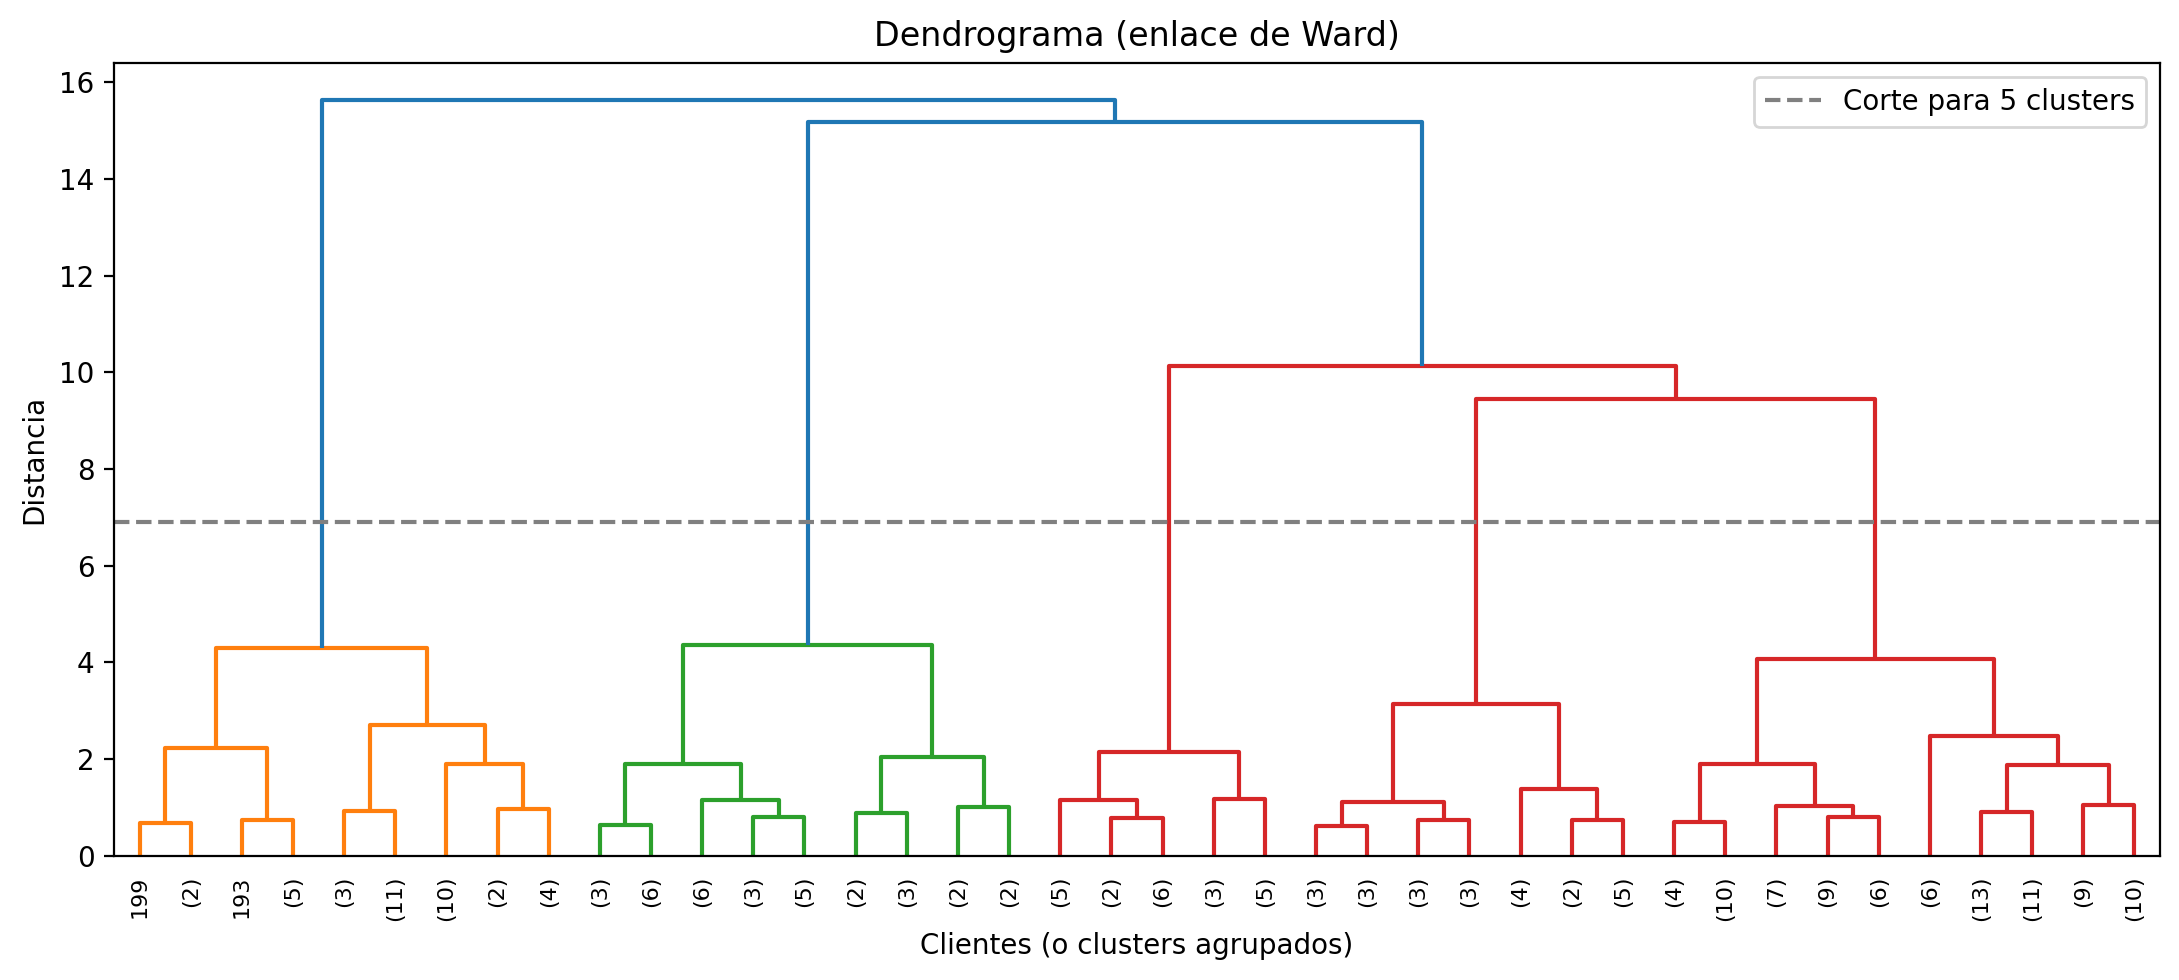

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

n = X_scaled.shape[0]
altura_corte = (Z[n - k_optimo - 1, 2] + Z[n - k_optimo, 2]) / 2

plt.figure(figsize=(11, 5), dpi=200)
dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=altura_corte, color="gray", linestyle="--", label=f"Corte para {k_optimo} clusters")
plt.title("Dendrograma (enlace de Ward)")
plt.xlabel("Clientes (o clusters agrupados)")
plt.ylabel("Distancia")
plt.legend()
plt.tight_layout()
plt.show()

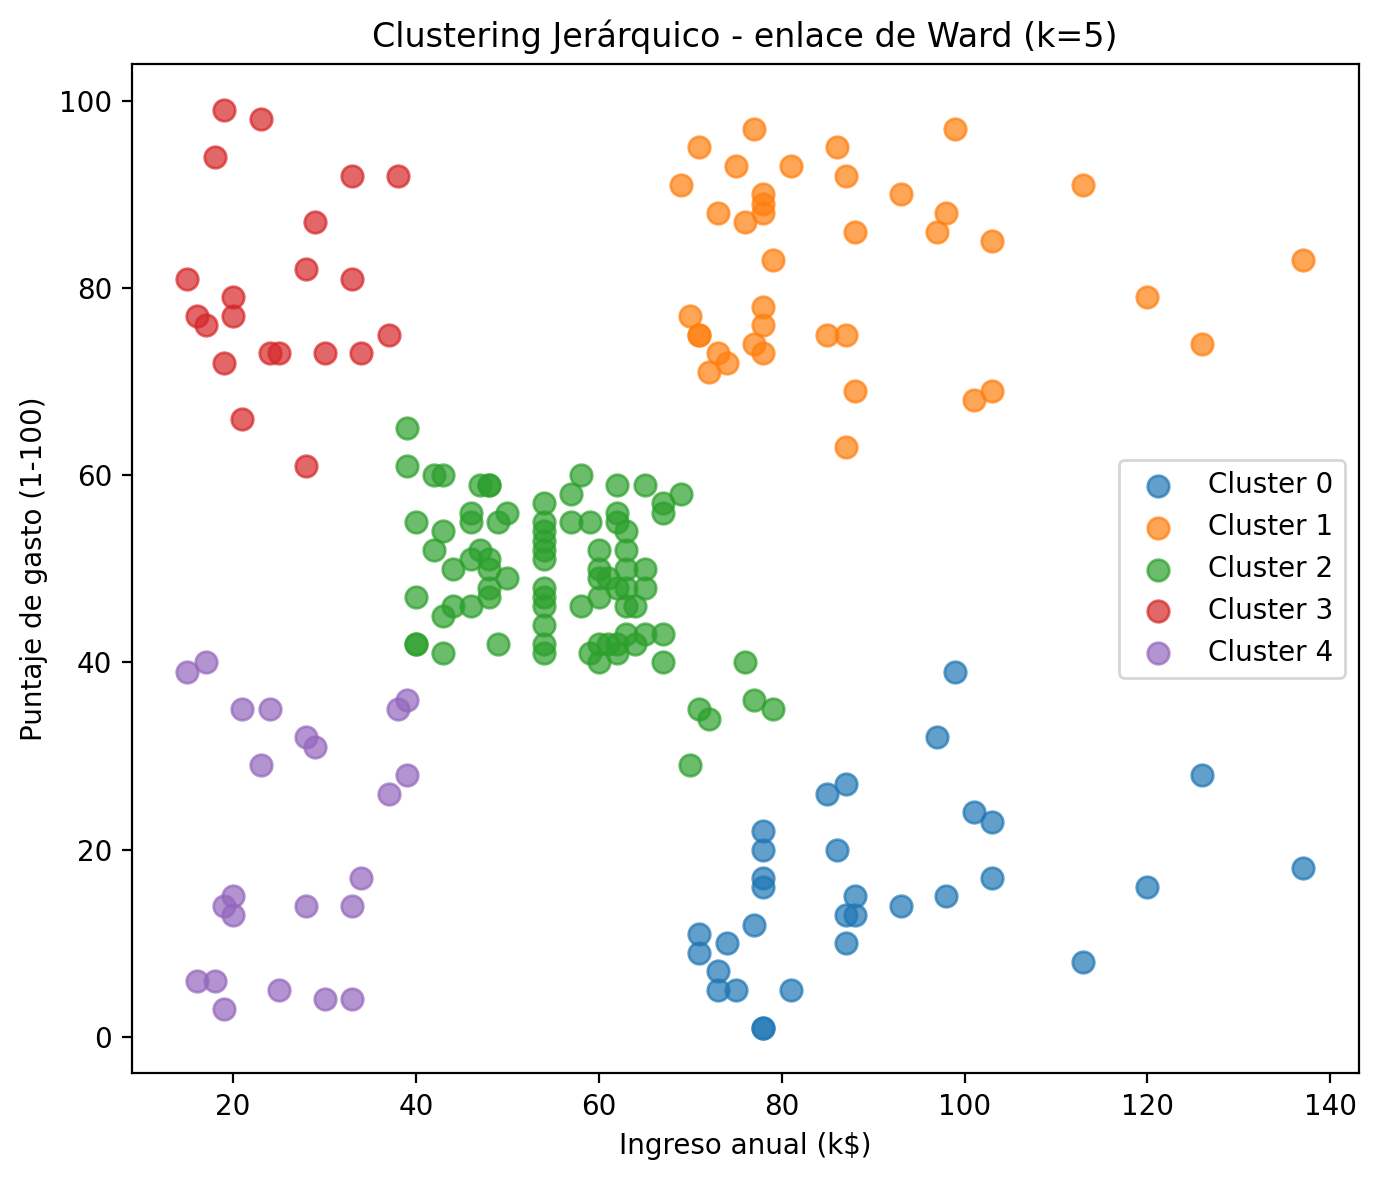

Jerárquico: mediana de tiempo de ajuste sobre 30 repeticiones = 0.0013 s


In [11]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=k_optimo, linkage="ward")
labels_agglo = agglo.fit_predict(X_scaled)

tiempos_agglo = []
for _ in range(30):
    t0 = time.perf_counter()
    AgglomerativeClustering(n_clusters=k_optimo, linkage="ward").fit(X_scaled)
    tiempos_agglo.append(time.perf_counter() - t0)
tiempo_agglo = float(np.median(tiempos_agglo))

plt.figure(figsize=(7, 6), dpi=200)
for c in range(k_optimo):
    plt.scatter(X[labels_agglo == c, 0], X[labels_agglo == c, 1], s=60, alpha=0.7, label=f"Cluster {c}")
plt.title(f"Clustering Jerárquico - enlace de Ward (k={k_optimo})")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Puntaje de gasto (1-100)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Jerárquico: mediana de tiempo de ajuste sobre 30 repeticiones = {tiempo_agglo:.4f} s")

# Evaluación de las máquinas de aprendizaje no supervisado

## Métricas internas

Este dataset no tiene una variable objetivo, así que no existen las métricas usadas en las prácticas de aprendizaje supervisado (exactitud, precisión, etc.): no hay una etiqueta "correcta" contra la cual comparar. En su lugar se usan **métricas internas de clustering**, que evalúan la calidad de una partición únicamente a partir de la estructura geométrica de los datos y las propias etiquetas de cluster asignadas:

| Métrica | Rango / referencia | Interpretación |
|---|---|---|
| **Silueta** (`silhouette_score`) | $[-1, 1]$, mayor es mejor | Qué tan bien encaja cada punto en su cluster frente al cluster vecino más cercano (ver fórmula $s(i)$ en la sección de Análisis) |
| **Índice de Davies-Bouldin** | $[0, \infty)$, **menor** es mejor | Promedio de la similitud entre cada cluster y su cluster "más parecido" (compacto y bien separado ⇒ valor bajo) |
| **Índice de Calinski-Harabasz** | $[0, \infty)$, mayor es mejor | Razón entre la dispersión **entre** clusters y la dispersión **dentro de** cada cluster (clusters compactos y separados ⇒ valor alto) |

Se calculan las tres métricas para K-Means y para el clustering jerárquico, sobre las mismas etiquetas de $k$ clusters, junto con el tiempo de ajuste de cada algoritmo.

In [12]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

resultados = {
    "K-Means": (labels_kmeans, tiempo_kmeans),
    "Jerárquico (Ward)": (labels_agglo, tiempo_agglo),
}

tabla_metricas = pd.DataFrame({
    nombre: {
        "Silueta": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Tiempo (s)": tiempo,
    }
    for nombre, (labels, tiempo) in resultados.items()
}).T
tabla_metricas.round(4)

,Silueta,Davies-Bouldin,Calinski-Harabasz,Tiempo (s)
K-Means,0.5547,0.5722,248.6493,0.0262
Jerárquico (Ward),0.5538,0.5779,244.4103,0.0013


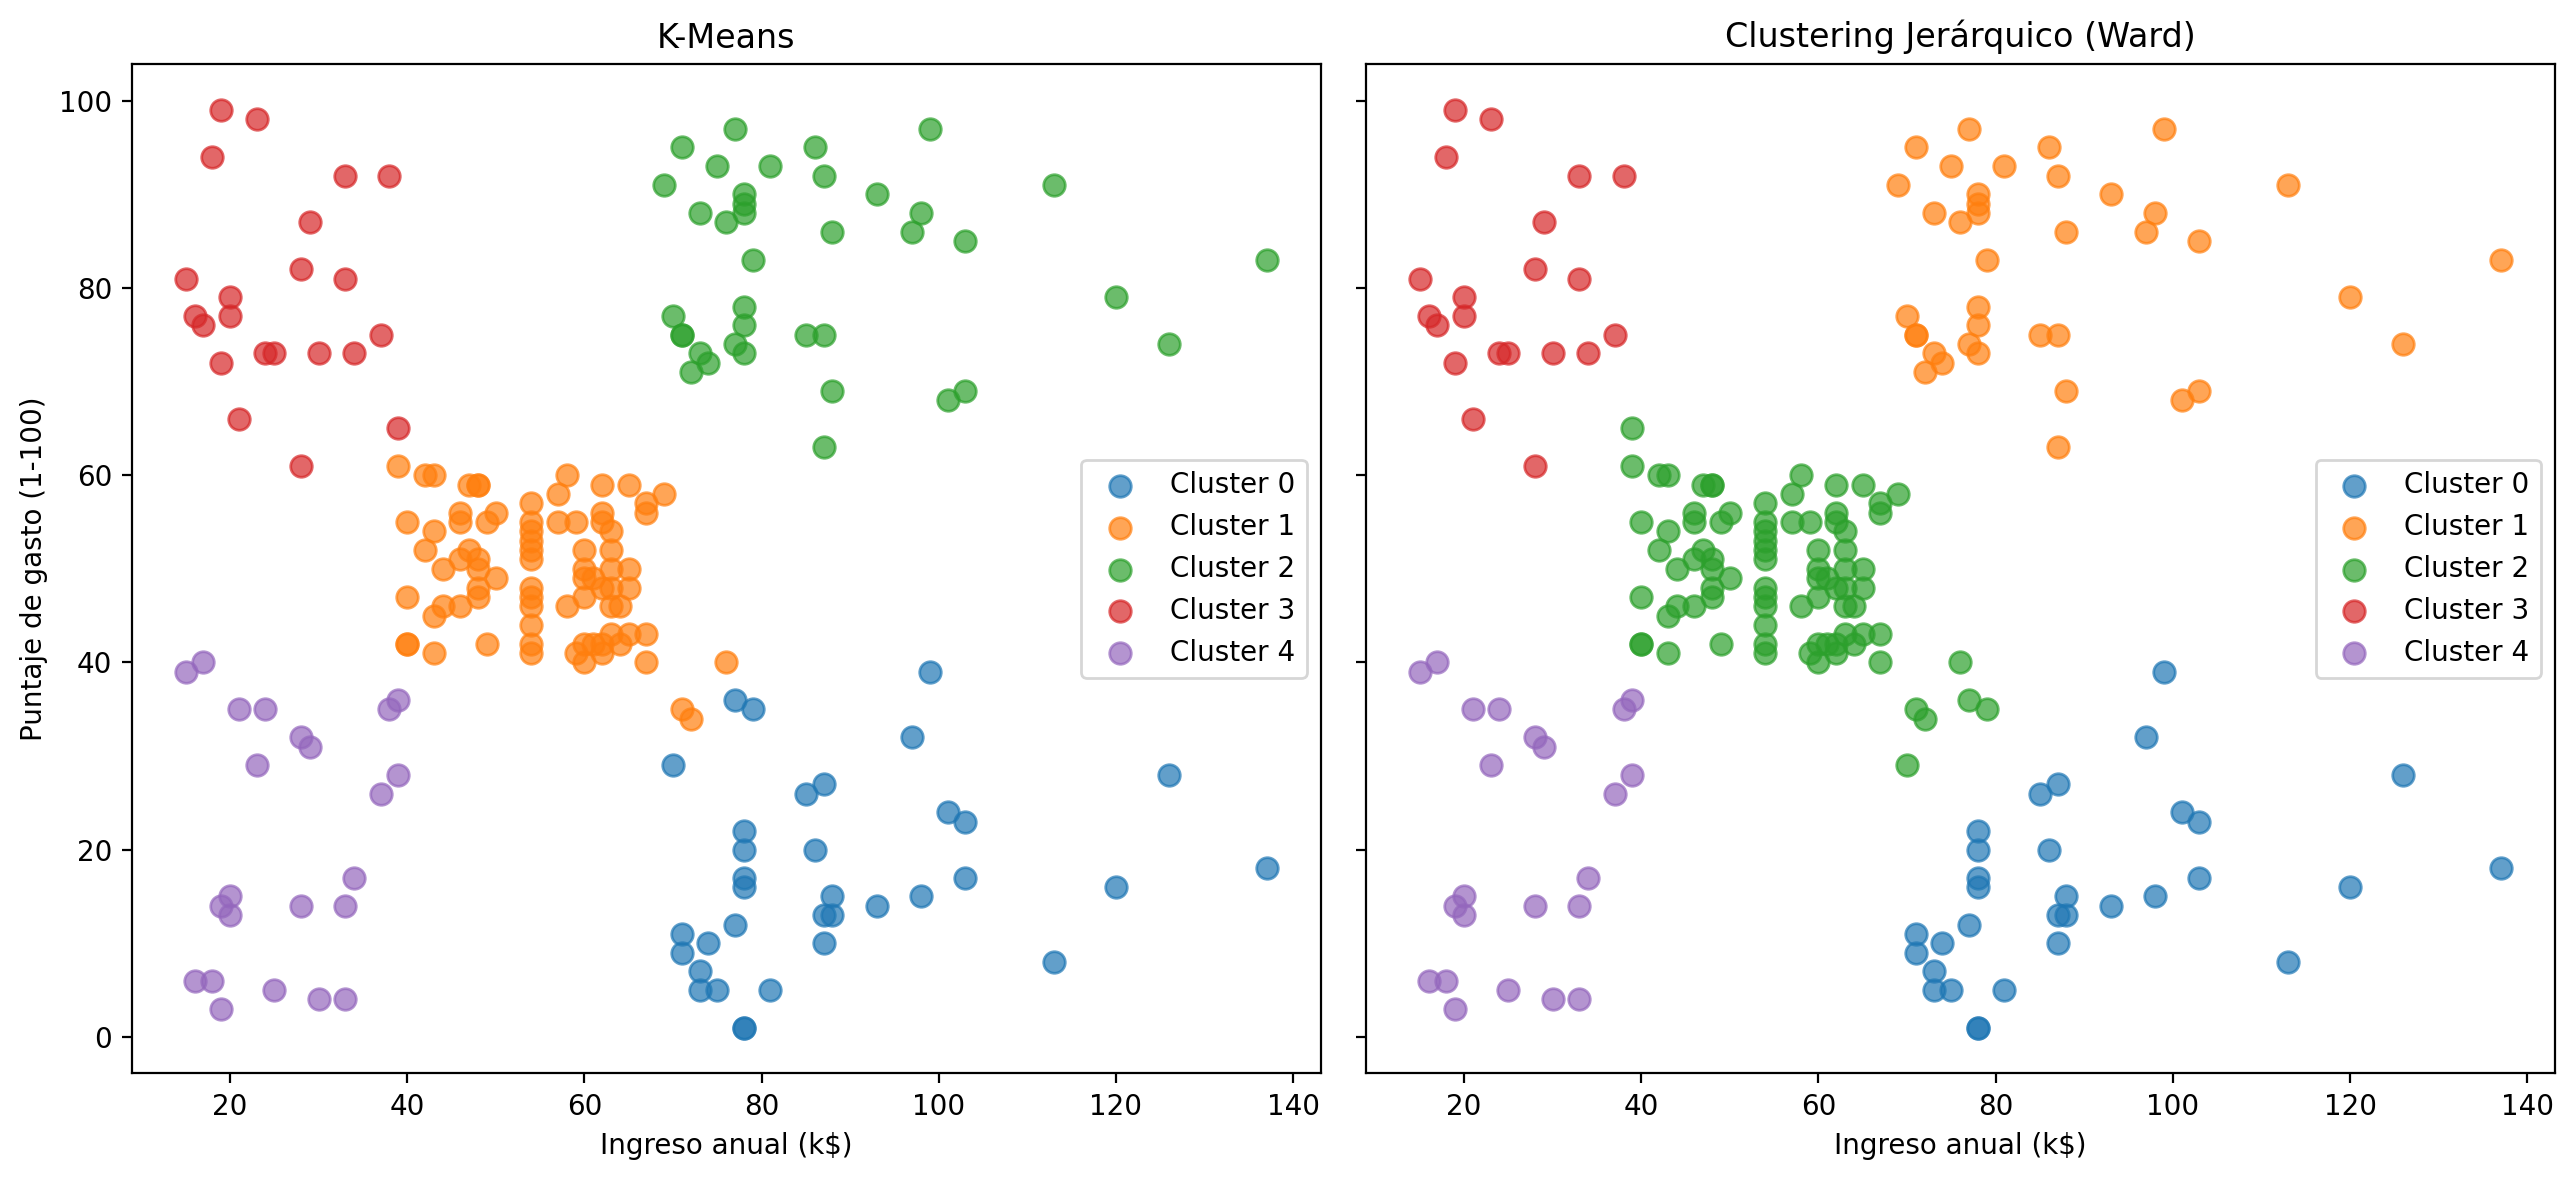

Adjusted Rand Index entre K-Means y Jerárquico: 0.9420


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=200, sharex=True, sharey=True)

for c in range(k_optimo):
    axes[0].scatter(X[labels_kmeans == c, 0], X[labels_kmeans == c, 1], s=60, alpha=0.7, label=f"Cluster {c}")
axes[0].set_title("K-Means")
axes[0].set_xlabel("Ingreso anual (k$)")
axes[0].set_ylabel("Puntaje de gasto (1-100)")
axes[0].legend()

for c in range(k_optimo):
    axes[1].scatter(X[labels_agglo == c, 0], X[labels_agglo == c, 1], s=60, alpha=0.7, label=f"Cluster {c}")
axes[1].set_title("Clustering Jerárquico (Ward)")
axes[1].set_xlabel("Ingreso anual (k$)")
axes[1].legend()

plt.tight_layout()
plt.show()

ari = adjusted_rand_score(labels_kmeans, labels_agglo)
print(f"Adjusted Rand Index entre K-Means y Jerárquico: {ari:.4f}")

## Análisis comparativo

Con $k=5$ (el valor que maximizó la silueta de K-Means, 0.5547) los resultados de ambos algoritmos, midiendo el tiempo de ajuste como la mediana de 30 repeticiones, fueron:

| Modelo | Silueta | Davies-Bouldin | Calinski-Harabasz | Tiempo (s) |
|---|---|---|---|---|
| K-Means | 0.5547 | 0.5722 | 248.6493 | 0.0281 |
| Jerárquico (Ward) | 0.5538 | 0.5779 | 244.4103 | 0.0008 |

**Lectura de resultados:**

- Las tres métricas internas quedaron **prácticamente empatadas** entre ambos algoritmos (silueta 0.5547 vs. 0.5538, Davies-Bouldin 0.5722 vs. 0.5779, Calinski-Harabasz 248.65 vs. 244.41): ninguno de los dos domina claramente al otro en calidad de agrupamiento sobre este dataset.
- El **Adjusted Rand Index** entre las dos particiones fue de **0.9420**, un valor muy cercano a 1: K-Means y el clustering jerárquico (con enlace de Ward) llegaron, de forma independiente y por caminos completamente distintos (centroides iterativos vs. fusiones sucesivas), a **prácticamente la misma partición** de los 200 clientes en 5 grupos. Esto es coherente con lo esperado en la sección de Análisis: el enlace de Ward persigue un objetivo (minimizar el incremento de varianza intra-cluster en cada fusión) muy similar en espíritu al de K-Means (minimizar la varianza intra-cluster total), por lo que ambos convergen a soluciones parecidas cuando los datos, como en este caso, presentan grupos razonablemente compactos y bien separados (visibles ya en el scatter de la sección exploratoria).
- En **tiempo de ejecución**, el clustering jerárquico resultó considerablemente más rápido en este caso concreto (0.0008 s frente a 0.0281 s de K-Means, ~35 veces menos). A primera vista esto contradice lo discutido en la sección de Análisis (complejidad $O(n^2 \log n)$ del jerárquico frente a $O(n \cdot k \cdot t)$ de K-Means), pero se explica por dos factores propios de esta configuración concreta: (1) `AgglomerativeClustering` con enlace de Ward realiza un único cálculo determinista, mientras que `KMeans` se configuró con `n_init=10`, es decir, repite el algoritmo de Lloyd completo 10 veces con distintas inicializaciones antes de quedarse con la mejor; y (2) con solo $n=200$ muestras, el costo absoluto de $O(n^2 \log n)$ sigue siendo diminuto, por lo que la ventaja asintótica de K-Means para datasets grandes todavía no se manifiesta. Con un número de clientes considerablemente mayor, se esperaría que esta relación se revirtiera.
- La ventaja práctica del clustering jerárquico en este ejercicio no se limita a la velocidad medida: el **dendrograma** también permitió decidir visualmente dónde cortar (y confirmar que 5 es un número de clusters razonable) sin tener que barrer $k$ explícitamente como se hizo con el método del codo y la silueta para K-Means.

# Conclusiones

Sobre el dataset **Mall Customer Segmentation Data**, usando `Annual Income (k$)` y `Spending Score (1-100)` como variables (previamente estandarizadas), tanto **K-Means** como el **clustering jerárquico aglomerativo** (enlace de Ward) identificaron **5 segmentos de clientes** prácticamente idénticos: un Adjusted Rand Index de 0.9420 confirma que ambos algoritmos, pese a construir la partición de forma completamente distinta (K-Means por reasignación iterativa a centroides; el jerárquico por fusiones sucesivas registradas en un dendrograma), coincidieron en casi todos los casos sobre a qué grupo pertenece cada cliente.

**Ningún algoritmo dominó al otro en calidad de agrupamiento**: las tres métricas internas (silueta, Davies-Bouldin, Calinski-Harabasz) resultaron casi idénticas entre ambos, lo que era esperable dado que el enlace de Ward persigue un objetivo de minimización de varianza intra-cluster muy cercano al de K-Means. En cuanto al **tiempo de ejecución**, el jerárquico fue considerablemente más rápido en esta práctica concreta (0.0008 s frente a 0.0281 s de K-Means) — no porque sea asintóticamente más eficiente (de hecho es al revés, $O(n^2 \log n)$ frente a $O(n \cdot k \cdot t)$), sino porque con solo 200 clientes ese costo cuadrático todavía es minúsculo en términos absolutos, mientras que K-Means, configurado con `n_init=10`, repitió el algoritmo de Lloyd completo diez veces. Con un dataset considerablemente más grande, esta relación se invertiría a favor de K-Means.

En cuanto a **cuándo preferir uno sobre otro**: si el dataset es grande y el número de segmentos ya se conoce (o se puede estimar rápido, como aquí con el método del codo y la silueta), **K-Means** escala mejor a largo plazo. Si, en cambio, no se tiene certeza sobre cuántos segmentos tiene sentido definir de negocio, o se quiere poder explorar distintos niveles de granularidad (2, 3, 5, 8 segmentos) sin volver a entrenar el modelo desde cero, el **dendrograma del clustering jerárquico** ofrece esa flexibilidad exploratoria — a cambio de un costo computacional que, a diferencia de lo observado en este dataset pequeño, se vuelve significativo cuando el número de muestras crece.

## Referencias

Vjchoudhary7. (s.f.). *Mall Customer Segmentation Data* [Dataset]. Kaggle. [https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. En *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability* (Vol. 1, pp. 281-297). University of California Press.

Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association*, 58(301), 236-244. [https://doi.org/10.1080/01621459.1963.10500845](https://doi.org/10.1080/01621459.1963.10500845)

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65. [https://doi.org/10.1016/0377-0427(87)90125-7](https://doi.org/10.1016/0377-0427(87)90125-7)

Scikit-learn developers. (s.f.). *sklearn.cluster.KMeans*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

Scikit-learn developers. (s.f.). *sklearn.cluster.AgglomerativeClustering*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Scikit-learn developers. (s.f.). *sklearn.metrics.silhouette_score*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261-272. [https://doi.org/10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)

Hernández Orallo, J., Ramírez Quintana, M. J., & Ferri Ramírez, C. (2004). *Introducción a la minería de datos*. Pearson Educación.

Hernández Parada, M. S. (2026). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%204.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20dos%20m%C3%A1quinas%20de%20aprendizaje%20no%20supervisado.ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%204.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20dos%20m%C3%A1quinas%20de%20aprendizaje%20no%20supervisado.ipynb)